In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np
import seaborn as sns

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
import category_encoders as ce

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score,confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_stata('data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)
df = df[df['v4'] >= 2000]

In [3]:
exclude = [f'v{i}' for i in [1,2] + list(range(8,18)) + list(range(46,48)) + list(range(54,71)) + list(range(78,82))]
exclude_also = [] # ['v7','v72','v55']
exclude_also = ['v7','v72','v22']
print(exclude)
df_reduced = df[[column for column in df.columns if column not in ['Version','doi','V81'] + exclude + exclude_also]]

['v1', 'v2', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v46', 'v47', 'v54', 'v55', 'v56', 'v57', 'v58', 'v59', 'v60', 'v61', 'v62', 'v63', 'v64', 'v65', 'v66', 'v67', 'v68', 'v69', 'v70', 'v78', 'v79', 'v80', 'v81']


In [4]:
df_reduced

,v3,v4,V4a,v5,v6,v18,v19,v20,v21,v23,...,v50,v51,v52,v53,v71,v73,v74,v75,v76,v77
345603,1,2000,1,1,1,2,1,0,0,0,...,0,0,4,0,0,1,4,12,0,8
345604,1,2000,1,1,2,2,1,0,0,0,...,0,0,4,0,0,0,4,12,0,8
345605,1,2000,1,1,18,2,2,0,0,0,...,0,0,4,0,4,0,1,12,0,8
345606,1,2000,1,4,99,2,3,0,0,0,...,0,0,4,0,0,0,4,12,0,8
345607,1,2000,1,1,6,3,2,0,0,0,...,0,0,4,0,0,2,4,17,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,12,2022,2,1,4,0,0,0,3,0,...,0,0,2,5,4,0,4,3,0,4
1046815,12,2022,2,1,4,0,0,0,2,0,...,0,0,4,0,4,2,3,1,0,1
1046816,12,2022,1,1,38,0,0,0,2,0,...,0,0,4,0,4,0,4,13,0,5
1046817,12,2022,1,4,99,0,0,0,3,0,...,0,0,4,0,0,0,4,14,0,4


In [5]:
partie_codes = {
    1  : 'CDU',
    2  : 'SPD',
    3  : 'FDP',
    4  : 'Gruene',
    6  : 'Linke',
    8  : 'NPD',
    49 : 'AfD',
    97 : 'undecided'
}

In [6]:
partie_code = 1
#years = [year for year in range(2010,2020)]
years = [year for year in range(2010,2020)]
#years = [2021]
target_question = 'v6'

In [7]:
# transform problem into binary classification problem
df_model_prep = df_reduced[(df_reduced['v4'].isin(years))].drop(['v3','v4'],axis=1)
left = [2,4,6]
right = [1,3,8,49]
df_model_pred = df_reduced[df_reduced['v6'].isin(left + right)]
df_model_prep['v6'] = df_model_prep['v6'].apply(lambda f: f in left)
#df_model_prep = df_model_prep[(df_model_prep['v22'] >= 1) & (df_model_prep['v22'] <= 10) & (df_model_prep['v22'] != 5)]
#df_model_prep['v22'] = df_model_prep['v22'].apply(lambda f: f<= 5)
df_model_prep

,V4a,v5,v6,v18,v19,v20,v21,v23,v24,v25,...,v50,v51,v52,v53,v71,v73,v74,v75,v76,v77
642800,1,1,False,3,0,0,1,0,0,4,...,0,0,2,5,0,2,4,17,0,5
642801,1,1,True,9,0,0,3,0,0,3,...,0,0,4,0,4,0,4,13,0,1
642802,1,1,False,3,0,0,1,0,0,2,...,0,0,4,0,4,3,4,14,0,1
642803,1,1,True,3,0,0,2,0,0,3,...,0,0,4,0,4,3,4,16,0,7
642804,1,1,False,2,0,0,3,0,0,3,...,0,0,2,6,0,3,4,16,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959740,2,1,True,0,0,0,1,0,0,2,...,1,3,5,0,0,3,4,5,0,6
959741,2,1,True,0,0,0,2,0,0,3,...,1,3,2,3,4,2,4,9,0,1
959742,2,1,True,0,0,0,1,0,0,2,...,1,1,4,0,4,2,4,3,0,5
959743,2,1,True,0,0,0,3,0,0,3,...,1,3,2,3,4,3,4,6,0,7


In [8]:
df_features = df_model_prep.drop([target_question], axis=1)
df_target = df_model_prep[target_question]
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2,stratify=df_target)


In [9]:
#Randomly spilt dataset to test and train set
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.1, stratify=df_target)
#Train SMOTE SRF


In [106]:
param_grid = { 'n_estimators': [50, 100, 200], 
               'max_depth': [None, 10, 20],
               'min_samples_split': [2, 5, 10] }
grid_search = GridSearchCV(BalancedRandomForestClassifier(),
                           param_grid=param_grid)
grid_search.fit(X_train, y_train)
print(grid_search.best_estimator_)

BalancedRandomForestClassifier(min_samples_split=10, n_estimators=200)


In [10]:
rf = BalancedRandomForestClassifier(max_depth=None, min_samples_split=10, n_estimators=200)
rf.fit(X_train, y_train)

BalancedRandomForestClassifier(min_samples_split=10, n_estimators=200)

In [11]:
y_pred = rf.predict(X_test)

Accuracy: 0.7518536046695062


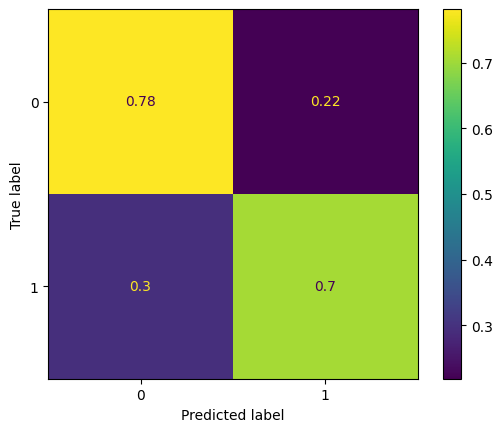

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred,normalize='true')).plot()

In [85]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.72      0.67      0.69      1894
        True       0.60      0.66      0.63      1433

    accuracy                           0.66      3327
   macro avg       0.66      0.66      0.66      3327
weighted avg       0.67      0.66      0.66      3327



In [86]:
# Extract feature importances
importances = rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:10].values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

   Feature  Importance
17     v34    0.099284
19     v36    0.098792
16     v33    0.094525
18     v35    0.090352
38     v75    0.072386
1       v5    0.069298
40     v77    0.065977
36     v73    0.058031
5      v21    0.044673
34     v53    0.040259
35     v71    0.029521
11     v28    0.027736
8      v25    0.026367
10     v27    0.024500
2      v18    0.023875
33     v52    0.023507
37     v74    0.022474
25     v42    0.018692
24     v41    0.013831
0      V4a    0.009873
12     v29    0.007860
23     v40    0.007592
32     v51    0.005911
3      v19    0.005831
31     v50    0.005714
14     v31    0.005018
13     v30    0.004767
28     v45    0.002317
27     v44    0.001038
7      v24    0.000000
6      v23    0.000000
4      v20    0.000000
9      v26    0.000000
21     v38    0.000000
22     v39    0.000000
20     v37    0.000000
15     v32    0.000000
29     v48    0.000000
30     v49    0.000000
26     v43    0.000000
39     v76    0.000000


In [151]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [153]:
y_pred = rf.predict(X_test)

In [154]:
accuracy_score(y_pred, y_test)

0.8181271606793927

In [156]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.84      0.95      0.89      5280
        True       0.61      0.32      0.42      1373

    accuracy                           0.82      6653
   macro avg       0.73      0.63      0.66      6653
weighted avg       0.80      0.82      0.79      6653



RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=50)


In [244]:
grid_search.fit(X_train_selected, y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]})

In [247]:
y_pred = grid_search.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7205384585456951


# Regression

In [233]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

regressor = RandomForestRegressor(n_estimators=50, random_state=0, oob_score=True)

regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, oob_score=True, random_state=0)

In [234]:
from sklearn.metrics import mean_squared_error, r2_score

oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

predictions = regressor.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y_test, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.05174923509232232
Mean Squared Error: 3.3864140805946423
R-squared: 0.08501614218547493


In [236]:
# Extract feature importances
importances = regressor.feature_importances_
feature_names = df_features.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:10].values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

   Feature  Importance
17     v34    0.135313
16     v33    0.115788
38     v75    0.087435
40     v77    0.085789
19     v36    0.064706
36     v73    0.048462
5      v21    0.048408
34     v53    0.039536
18     v35    0.039354
11     v28    0.033300
8      v25    0.030776
33     v52    0.030144
35     v71    0.030017
2      v18    0.029840
10     v27    0.028139
37     v74    0.027341
25     v42    0.024590
24     v41    0.018238
1       v5    0.017473
12     v29    0.011087
23     v40    0.010227
3      v19    0.007461
32     v51    0.007339
14     v31    0.006903
31     v50    0.006704
13     v30    0.006459
0      V4a    0.004848
28     v45    0.003101
27     v44    0.001221
7      v24    0.000000
6      v23    0.000000
4      v20    0.000000
9      v26    0.000000
21     v38    0.000000
22     v39    0.000000
20     v37    0.000000
15     v32    0.000000
29     v48    0.000000
30     v49    0.000000
26     v43    0.000000
39     v76    0.000000
